# Neural Network Model on Pet Breed Classification 

### Transfer Learning

Transfer learning is a machine learning technique where a pre-trained model (e.g., trained on ImageNet) is repurposed for a new, related task.   
It boosts performance, reduces training time, and solves data scarcity issues by leveraging learned features.  
Common approaches include freezing early layers and fine-tuning the last layers.

In [1]:
# importing essential libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import keras  
from keras import layers
from tensorflow import data as tf_data

### Using the Oxford-IIIT Pet Dataset
train_dataset $\rightarrow$ First 80% of the training set, used to train the neural network  
validation_dataset $\rightarrow$ Last 20% of the training set, used to tune hyperparameters, helps detect overfitting  
test_dataset $\rightarrow$ Completely separate dataset, used only for final model evaluation  
shuffle_files = True $\rightarrow$ Ensures that the dataset files are randomly shuffled before loading, which helps prevent learning bias caused by ordered data.  
as_supervised = True $\rightarrow$ Each element of the dataset is returned as a pair: (input image, class label)

In [2]:
# getting data from the dataset of 'oxford_iiit_pet:4.0.0'
# This dataset contains 37 pet breeds
# dividing them to train, validation and test datasets
train_dataset, validation_dataset, test_dataset = tfds.load(
    'oxford_iiit_pet:4.0.0',
    split=["train[0%:80%]", "train[80%:100%]", "test"],
    shuffle_files=True,
    as_supervised=True
)

In [3]:
# checking the number of data samples in each dataset
print(f"Number of training samples: {train_dataset.cardinality()}")
print(f"Number of validation samples: {validation_dataset.cardinality()}")
print(f"Number of test samples: {test_dataset.cardinality()}")

Number of training samples: 2944
Number of validation samples: 736
Number of test samples: 3669


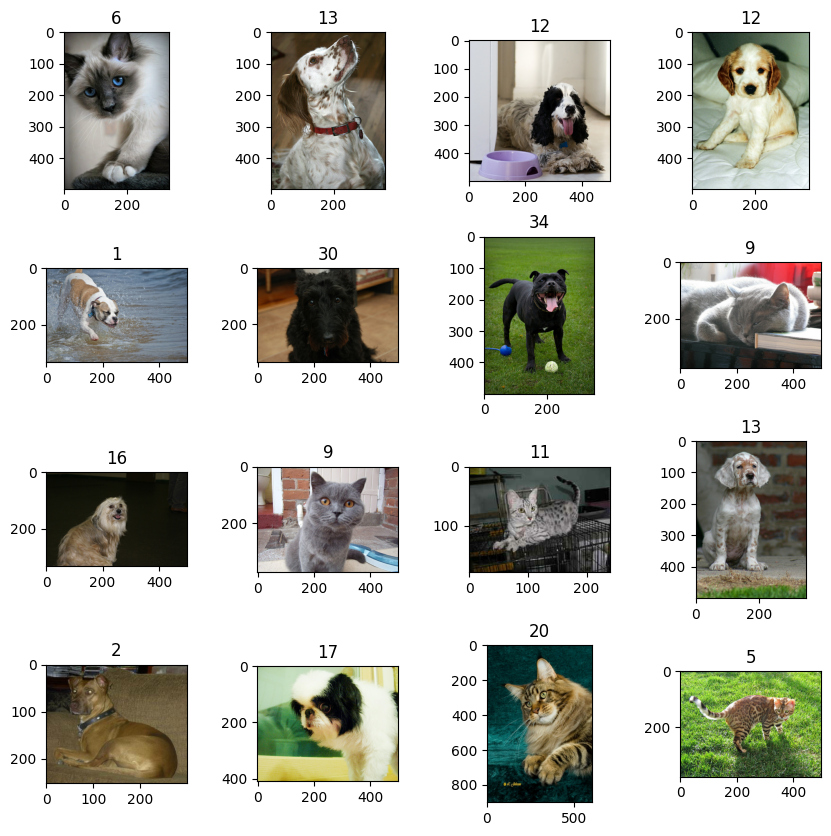

In [4]:
# checking the first 16 images in the train dataset
# integer above the image shows the pet breed it belong to
# The images are not in a same size
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_dataset.take(16)):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(image)
    plt.title(int(label))
    plt.axis("on")
plt.subplots_adjust(wspace=0.5, hspace=0.3)

### Data Preprocessing
This resizes every image to: 224 x 224, Because ResNet expects input images of size $\rightarrow$ 224×224×3  
cast $\rightarrow$ Images may originally be stored as integers: Casting converts them to float32 datatype, which neural networks require.  
preprocess_input $\rightarrow$ This performs the ResNet normalization. ResNet preprocessing typically transforms pixel values roughly like:  
$$
x_{norm} = x − μ
$$

where μ is the ImageNet mean value for each channel.  
This ensures the input distribution matches the data used to train ResNet on ImageNet.  
The .map() function applies process_image() function to every sample in the dataset.

In [5]:
def process_image(image, label):
    image = tf.image.resize(image, (224, 224)) # Resizing to the relevant size
    image = tf.keras.applications.resnet.preprocess_input(tf.cast(image, tf.float32)) # Normalizing
    return image, label

train_dataset = train_dataset.map(process_image)
validation_dataset = validation_dataset.map(process_image)
test_dataset = test_dataset.map(process_image)

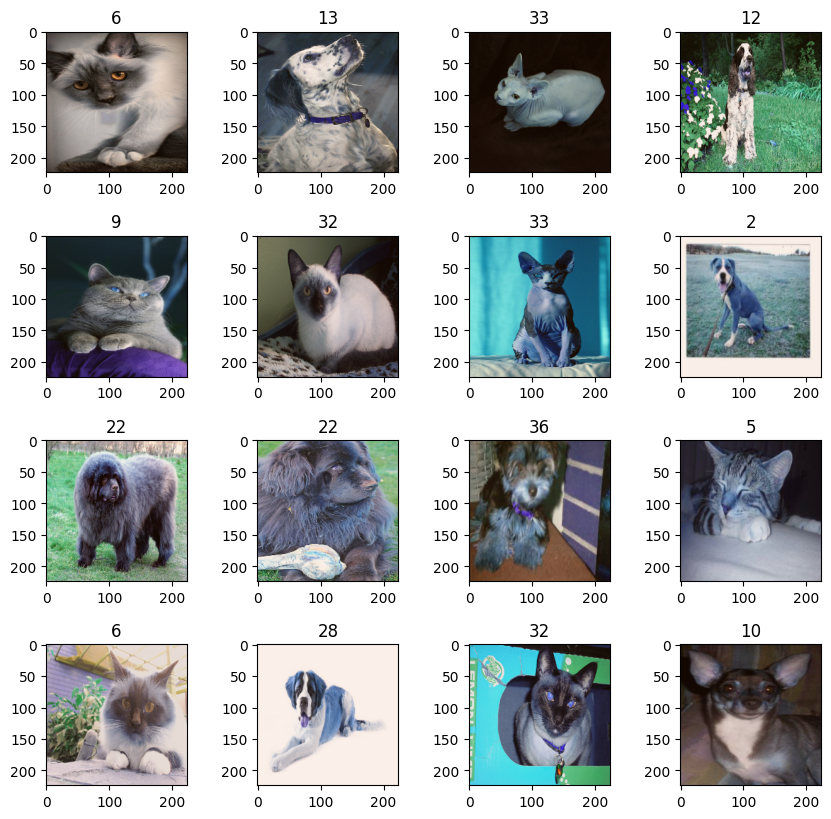

In [6]:
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_dataset.take(16)):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow((image + 125)/280)
    plt.title(int(label))
    plt.axis("on")
plt.subplots_adjust(wspace=0.5, hspace=0.3)
plt.show()

### Data Augmentation

To improve model generalization, data augmentation is applied to the training images.  
This process artificially increases the diversity of the dataset by applying random transformations.  
The .map() function applies the augmentation to every training sample.

$$
(x, y) \rightarrow (x_{aug}, y)
$$

In [7]:
# introducing flippings and small rotations to the dataset
augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x

train_dataset = train_dataset.map(lambda x, y: (data_augmentation(x), y))

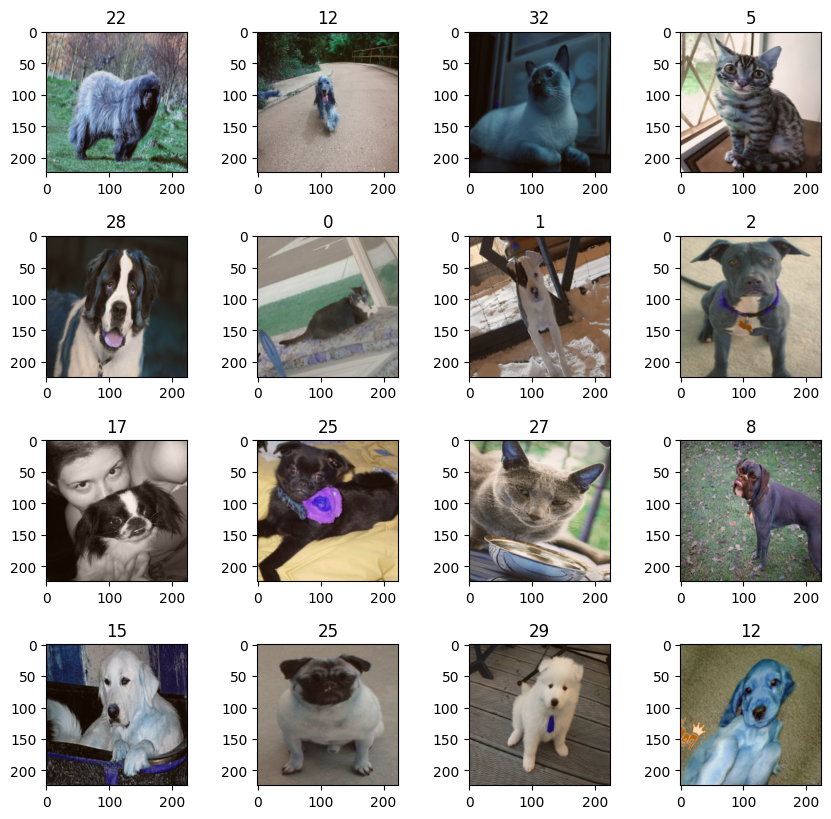

In [8]:
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_dataset.take(16)):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow((image + 125)/280)
    plt.title(int(label))
    plt.axis("on")
plt.subplots_adjust(wspace=0.5, hspace=0.3)
plt.show()

### Preparing the Dataset Pipeline
preparing the dataset pipeline using TensorFlow tf.data API so that training runs faster and more efficiently  
For that the dataset is processed using batching, caching, and prefetching.  
batch $\rightarrow$ This groups samples into batches of 32 images. Instead of feeding the model one image at a time, it feeds 32 images together.  
prefetch $\rightarrow$ This means prepare the next batch while the current batch is training.  
cache $\rightarrow$ Stores the dataset in memory after the first epoch.

In [9]:
batch_size = 32

train_dataset = train_dataset.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
validation_dataset = validation_dataset.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
test_dataset = test_dataset.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()

### Loading weights of pre-trained ResNet50 model on ImageNet
ImageNet contains: ~1.2 million images, 1000 object categories.  
Because of this training, the model already knows how to detect: edges, textures, shapes, object structures  
So we reuse this knowledge instead of training from scratch.  
ResNet50 originally ends with a classifier like: Dense(1000) Softmax. That is for ImageNet's 1000 classes.  
include_top=False $\rightarrow$ This Removes the ImageNet classifier at the top of the model  
  
trainable = False $\rightarrow$ Freeze the base_model. Freezing means the pretrained parameters remain unchanged during training.  
weight_decay $\rightarrow$ This value controls L2 regularization strength. Here, $\lambda$ = weight decay. This penalizes large weights, reduces overfitting.  
$$
L = L_{data} + \lambda \sum_i{w_i^2}
$$

inputs = keras.Input() $\rightarrow$ Defining the input layer. This creates the input tensor of the neural network.  
base_model(inputs, training=False) $\rightarrow$ The image is passed to the pretrained ResNet50 convolutional layers. Here network will extract deep visual features.  
ResNet contains Batch Normalization layers. Setting "training=False" ensures they operate in inference mode instead of recalculating statistics during training.
$$
μ, σ^2 = \textrm {ImageNet Statistics}
$$
GlobalAveragePooling2D() $\rightarrow$ If the feature map is $H × W × C$. then global average pooling computes:
$$
z_c=\frac{1}{HW}\sum_{i=1}^{H}\sum_{j=1}^{W}x_{i,j,c} \qquad z∈R^C \qquad Ex: 7 \times 7 \times 2048 \rightarrow 2048
$$
outputs = keras.layers.Dense $\rightarrow$ This layer predicts the 37 pet breeds. Softmax converts logits into probabilities.  
model = keras.Model $\rightarrow$ creating the model architecture by defining the inputs and outputs

In [10]:
base_model = tf.keras.applications.resnet50.ResNet50(weights='imagenet',
                                                     include_top=False,
                                                     input_shape=(224,224,3))

base_model.trainable = False
weight_decay = 0.01

inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
outputs = keras.layers.Dense(37, activation='softmax',kernel_regularizer=tf.keras.regularizers.l2(weight_decay))(x)
model = keras.Model(inputs, outputs)

model.summary(show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ resnet50 (Functional)       │ (None, 7, 7, 2048)    │ 23,587,712 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 37)            │     75,813 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 23,663,525 (90.27 MB)

 Trainable params: 75,813 (296.14 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Model Training with Transfer Learning
During training the model will compute classification accuracy. Accuracy formula:
$$
Accuracy = \frac{\textrm {Number of Correct Predictions}}{\textrm {Total Predictions}}
$$
If the dataset has $N$ samples and batch size is $B$:
$$
\textrm {Iterations per epoch} = \frac{N}{B}
$$

In [11]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005,weight_decay=weight_decay),
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

callback = keras.callbacks.EarlyStopping(monitor='val_loss',patience=3, verbose=1,mode="min",restore_best_weights=True)
model.fit(train_dataset, epochs=5, callbacks=[callback], validation_data=validation_dataset)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 405s 4s/step - accuracy: 0.2745 - loss: 3.6155 - val_accuracy: 0.7731 - val_loss: 1.5895
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 432s 5s/step - accuracy: 0.8457 - loss: 1.3977 - val_accuracy: 0.8655 - val_loss: 1.2161
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 499s 5s/step - accuracy: 0.9252 - loss: 1.0581 - val_accuracy: 0.8791 - val_loss: 1.0595
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 417s 5s/step - accuracy: 0.9517 - loss: 0.8839 - val_accuracy: 0.8899 - val_loss: 0.9524
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 242s 3s/step - accuracy: 0.9664 - loss: 0.7619 - val_accuracy: 0.8954 - val_loss: 0.8689
Restoring model weights from the end of the best epoch: 5.


In [12]:
print("Test dataset evaluation")
model.evaluate(test_dataset)

Test dataset evaluation
115/115 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.8659 - loss: 0.9481


[0.9598749279975891, 0.86045241355896]

In [13]:
base_model = tf.keras.applications.resnet50.ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3), pooling=max)
base_model.trainable = True

In [14]:
weight_decay = 0.001
model_new = tf.keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(37, activation='softmax',kernel_regularizer=tf.keras.regularizers.l2(weight_decay))
])

model_new.summary(show_trainable=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ resnet50 (Functional)       │ (None, 7, 7, 2048)    │ 23,587,712 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_1  │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 37)            │     75,813 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 23,663,525 (90.27 MB)

 Trainable params: 23,610,405 (90.07 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [15]:

# Compile the model with a lower learning rate to fine-tune the unfrozen layers
model_new.compile(optimizer=keras.optimizers.Adam(learning_rate=0.00005,weight_decay=weight_decay),
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

callback = keras.callbacks.EarlyStopping(monitor='val_loss',patience=5, verbose=1,mode="min",restore_best_weights=True)
# Train the model with the same callbacks and epochs
model_new.fit(train_dataset, epochs=5, callbacks=[callback], validation_data=validation_dataset)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 1066s 11s/step - accuracy: 0.2432 - loss: 3.1407 - val_accuracy: 0.7989 - val_loss: 0.7338
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 1060s 12s/step - accuracy: 0.9230 - loss: 0.4526 - val_accuracy: 0.8641 - val_loss: 0.5241
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 2008s 22s/step - accuracy: 0.9955 - loss: 0.1493 - val_accuracy: 0.8750 - val_loss: 0.4743
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 1661s 18s/step - accuracy: 1.0000 - loss: 0.1001 - val_accuracy: 0.8696 - val_loss: 0.4722
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 1062s 11s/step - accuracy: 1.0000 - loss: 0.0874 - val_accuracy: 0.8709 - val_loss: 0.4689
Restoring model weights from the end of the best epoch: 5.


In [16]:
print("Test dataset evaluation")
model_new.evaluate(test_dataset)

Test dataset evaluation
115/115 ━━━━━━━━━━━━━━━━━━━━ 229s 2s/step - accuracy: 0.8707 - loss: 0.5060


[0.5193344950675964, 0.867811381816864]